# Muziekclassificatie — Visualisatie

**Project R.E.M. · Visualisatie-notebook**

Laadt de resultaten van het drempelwaarde-classificatiemodel en visualiseert de uitkomsten per deelnemer.
Geen modeltraining — alleen laden en visualiseren.

**Vereiste invoer:**
- `models/music_classification/{codename}_config.json`
- `data/analysis/{codename}/classified_songs.csv`

In [1]:
from __future__ import annotations

import json
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


In [2]:
# ── Configuratie ──────────────────────────────────────────────────────────────
PARTICIPANT = "all"   # "all" of bijv. "peer"

# ── Paden ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path().resolve().parent.parent
ANALYSIS_DIR = PROJECT_ROOT / "data" / "analysis"
MODELS_DIR   = PROJECT_ROOT / "models" / "music_classification"

# ── Visuele stijl (donker thema) ──────────────────────────────────────────────
DARK = {
    "figure.facecolor": "#0f1218",
    "axes.facecolor":   "#181e2a",
    "axes.edgecolor":   "#4a5568",
    "axes.labelcolor":  "#e2e8f0",
    "xtick.color":      "#e2e8f0",
    "ytick.color":      "#e2e8f0",
    "text.color":       "#e2e8f0",
    "grid.color":       "#2d3748",
    "grid.alpha":       0.5,
    "font.family":      "monospace",
    "legend.facecolor": "#1a2035",
    "legend.edgecolor": "#4a5568",
}
plt.rcParams.update(DARK)
plt.rcParams["figure.dpi"] = 120

CLASS_COLORS = {"calm": "#56b4e9", "energy": "#e69f00", "other": "#999999"}
CLASS_ORDER  = ["calm", "energy", "other"]

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"PARTICIPANT  : {PARTICIPANT}")

PROJECT_ROOT : C:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project
PARTICIPANT  : all


---
## 1. Data laden

In [3]:
def detect_participants() -> list[str]:
    """Detecteer alle deelnemers met geclassificeerde data."""
    return sorted(
        p.name for p in ANALYSIS_DIR.iterdir()
        if p.is_dir() and (p / "classified_songs.csv").exists()
    )


def load_participant(codename: str) -> tuple[pd.DataFrame, dict]:
    """Laad classified_songs.csv en config.json voor één deelnemer."""
    csv_path    = ANALYSIS_DIR / codename / "classified_songs.csv"
    config_path = MODELS_DIR / f"{codename}_config.json"

    if not csv_path.exists():
        raise FileNotFoundError(
            f"Geclassificeerde data niet gevonden voor '{codename}'.\n"
            f"Verwacht: {csv_path}\n"
            f"Voer eerst notebooks/ml/music_class_thresholds.ipynb uit."
        )
    if not config_path.exists():
        raise FileNotFoundError(
            f"Config niet gevonden voor '{codename}'.\n"
            f"Verwacht: {config_path}\n"
            f"Voer eerst notebooks/ml/music_class_thresholds.ipynb uit."
        )

    df = pd.read_csv(csv_path)
    with open(config_path, encoding="utf-8") as f:
        config = json.load(f)

    return df, config


# Deelnemers bepalen
if PARTICIPANT == "all":
    participants = detect_participants()
    if not participants:
        raise FileNotFoundError(
            f"Geen classified_songs.csv gevonden onder {ANALYSIS_DIR}.\n"
            "Voer eerst notebooks/ml/music_class_thresholds.ipynb uit."
        )
else:
    participants = [PARTICIPANT]

# Data laden
data: dict[str, tuple[pd.DataFrame, dict]] = {}
for codename in participants:
    df, config = load_participant(codename)
    data[codename] = (df, config)
    print(f"  {codename}: {len(df)} nummers, klassen: {df['class'].value_counts().to_dict()}")

print(f"\n{len(participants)} deelnemer(s) geladen.")

  courgette: 5720 nummers, klassen: {'other': 4417, 'energy': 737, 'calm': 566}
  peer: 691 nummers, klassen: {'other': 542, 'energy': 96, 'calm': 53}

2 deelnemer(s) geladen.


---
## 2. Klasseverdeling per deelnemer

Hoeveel nummers vallen in elke klasse? Grote 'OTHER'-klasse is normaal — die is bedoeld als opvangnet voor alles wat niet duidelijk calm of energetisch is.

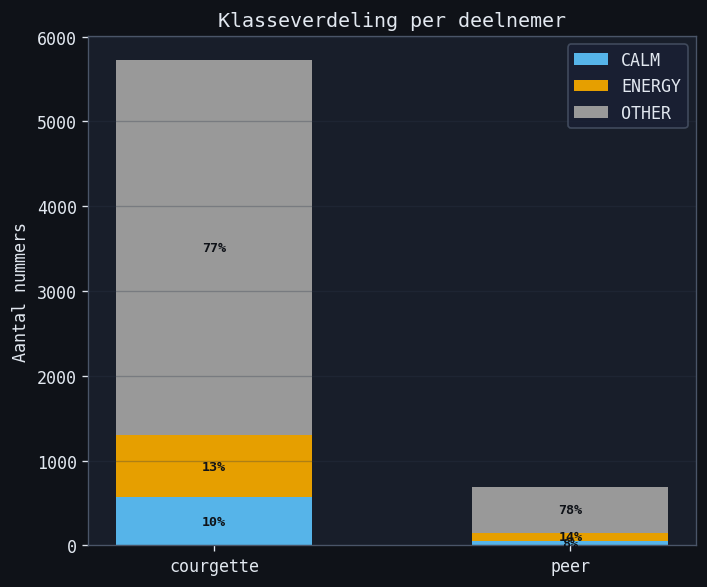

In [4]:
fig, ax = plt.subplots(figsize=(max(6, len(participants) * 2), 5))

x      = np.arange(len(participants))
bottom = np.zeros(len(participants))

for cls in CLASS_ORDER:
    counts = [
        (data[p][0]["class"] == cls).sum() for p in participants
    ]
    bars = ax.bar(x, counts, bottom=bottom, color=CLASS_COLORS[cls],
                  label=cls.upper(), width=0.55, edgecolor="none")

    # Percentage-annotatie in het balkje (alleen als groot genoeg)
    totals = [len(data[p][0]) for p in participants]
    for i, (bar, count, total) in enumerate(zip(bars, counts, totals)):
        pct = count / total * 100
        if pct > 4:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[i] + count / 2,
                f"{pct:.0f}%",
                ha="center", va="center",
                fontsize=8, color="#0f1218", fontweight="bold",
            )
    bottom += np.array(counts, dtype=float)

ax.set_xticks(x)
ax.set_xticklabels(participants)
ax.set_ylabel("Aantal nummers")
ax.set_title("Klasseverdeling per deelnemer")
ax.legend(loc="upper right")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. Arousal-score verdeling

Hoe zijn de arousal-scores verdeeld per klasse? De stippellijnen tonen de classificatiedrempels. Een goede classificatie heeft duidelijk gescheiden pieken voor CALM (links) en ENERGY (rechts).

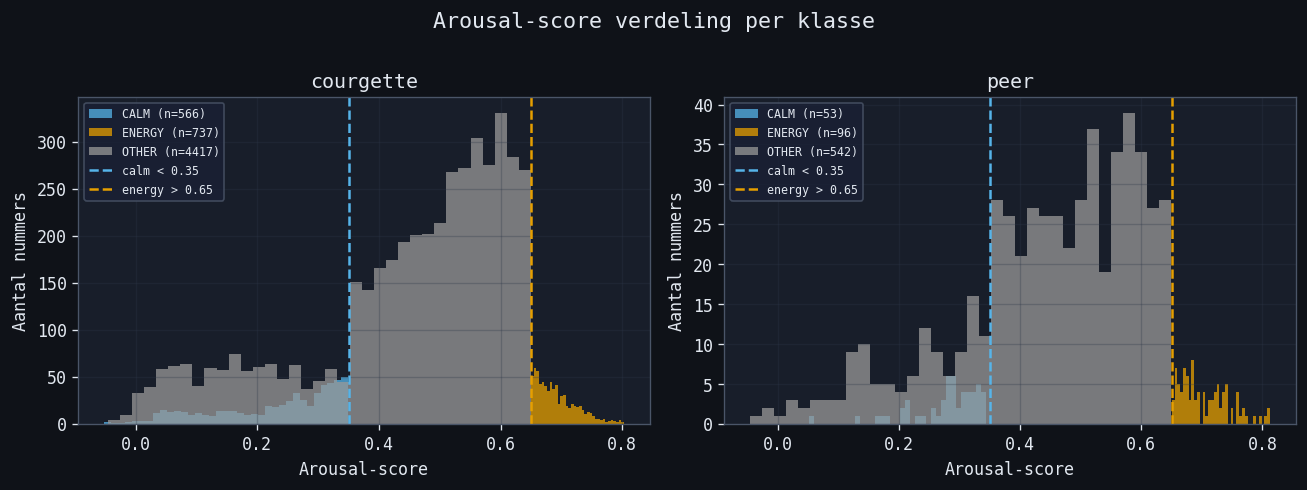

In [5]:
n_cols = min(2, len(participants))
n_rows = math.ceil(len(participants) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(11 * n_cols / 2, 4 * n_rows), squeeze=False)

for idx, codename in enumerate(participants):
    df, config = data[codename]
    ax = axes[idx // n_cols][idx % n_cols]

    calm_thresh   = config["thresholds"]["calm"]
    energy_thresh = config["thresholds"]["energy"]

    for cls in CLASS_ORDER:
        subset = df[df["class"] == cls]["arousal_score"].dropna()
        if len(subset) == 0:
            continue
        ax.hist(subset, bins=35, color=CLASS_COLORS[cls], alpha=0.75,
                label=f"{cls.upper()} (n={len(subset)})", edgecolor="none")

    ax.axvline(calm_thresh,   color="#56b4e9", linestyle="--", linewidth=1.5,
               label=f"calm < {calm_thresh}")
    ax.axvline(energy_thresh, color="#e69f00", linestyle="--", linewidth=1.5,
               label=f"energy > {energy_thresh}")

    ax.set_title(codename)
    ax.set_xlabel("Arousal-score")
    ax.set_ylabel("Aantal nummers")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

for idx in range(len(participants), n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].set_visible(False)

fig.suptitle("Arousal-score verdeling per klasse", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Radar chart — gemiddeld kenmerkprofiel per klasse

Wat maakt een CALM-nummer anders dan een ENERGY-nummer? De radar toont de gemiddelde waarden van elk audio-kenmerk per klasse. Een goede classificatie geeft duidelijk verschillende profielen: CALM scoort hoog op acousticness, ENERGY hoog op tempo en energy.

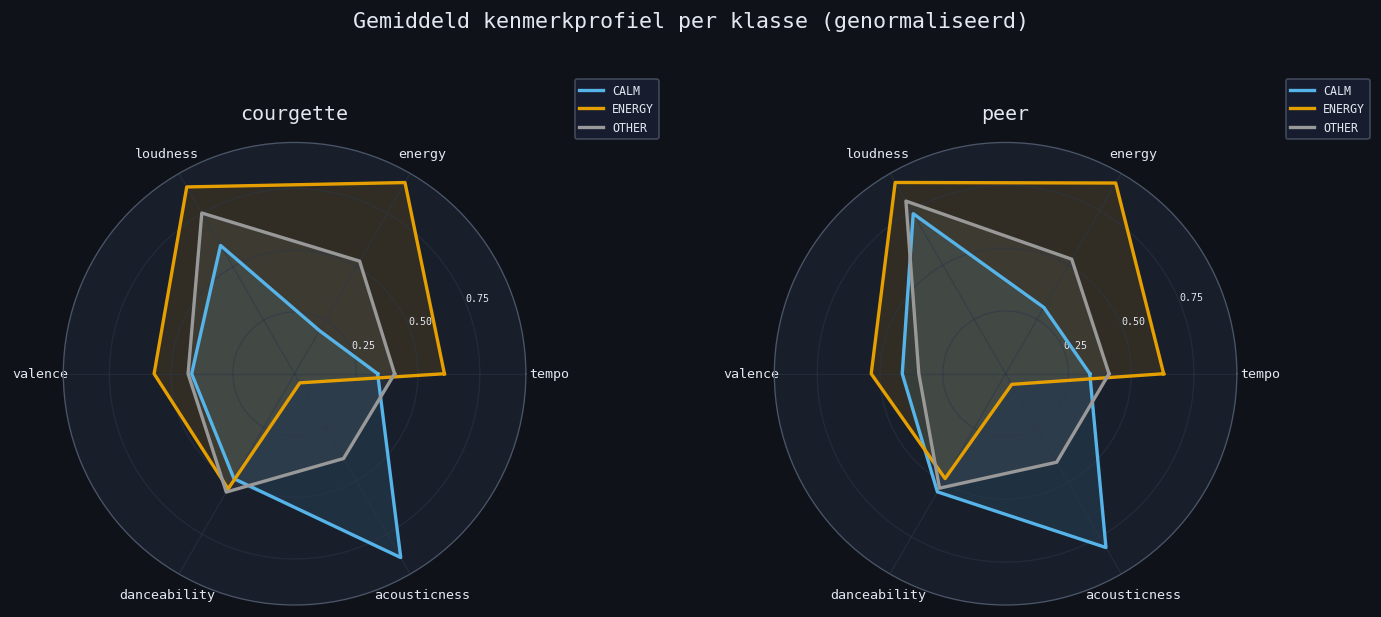

In [6]:
RADAR_FEATURES = ["tempo", "energy", "loudness", "valence", "danceability", "acousticness"]

# Normaliseer naar [0,1] over alle deelnemers samen voor vergelijkbaarheid
all_songs = pd.concat([df for df, _ in data.values()], ignore_index=True)
feat_min  = all_songs[RADAR_FEATURES].min()
feat_max  = all_songs[RADAR_FEATURES].max()


def normalize(df_sub: pd.DataFrame) -> pd.DataFrame:
    return (df_sub[RADAR_FEATURES] - feat_min) / (feat_max - feat_min + 1e-9)


n_feat   = len(RADAR_FEATURES)
angles   = np.linspace(0, 2 * np.pi, n_feat, endpoint=False).tolist()
angles  += angles[:1]  # sluit de cirkel

n_cols = min(2, len(participants))
n_rows = math.ceil(len(participants) / n_cols)
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(6 * n_cols, 5 * n_rows),
    subplot_kw={"projection": "polar"},
    squeeze=False,
)

for idx, codename in enumerate(participants):
    df, _ = data[codename]
    ax = axes[idx // n_cols][idx % n_cols]
    ax.set_facecolor("#181e2a")

    for cls in CLASS_ORDER:
        subset = df[df["class"] == cls]
        if len(subset) == 0:
            continue
        means  = normalize(subset).mean().tolist()
        values = means + means[:1]
        ax.plot(angles, values, color=CLASS_COLORS[cls], linewidth=2, label=cls.upper())
        ax.fill(angles, values, color=CLASS_COLORS[cls], alpha=0.12)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(RADAR_FEATURES, fontsize=8)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(["0.25", "0.50", "0.75"], fontsize=6, color="#4a5568")
    ax.tick_params(colors="#e2e8f0")
    ax.set_title(codename, pad=14)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.15), fontsize=7)
    ax.grid(color="#2d3748", alpha=0.5)

for idx in range(len(participants), n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].set_visible(False)

fig.suptitle("Gemiddeld kenmerkprofiel per klasse (genormaliseerd)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Feature boxplots per klasse

Detailweergave van de vier belangrijkste kenmerken. De spreiding binnen een klasse laat zien hoe homogeen de groep is — een smalle box betekent consistente nummers.

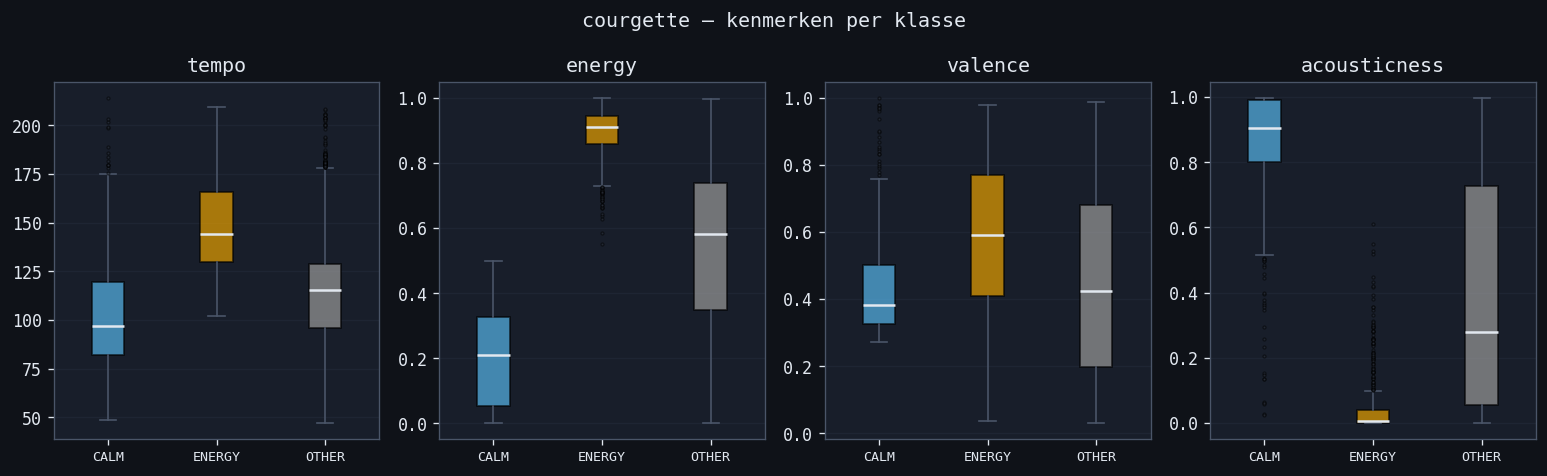

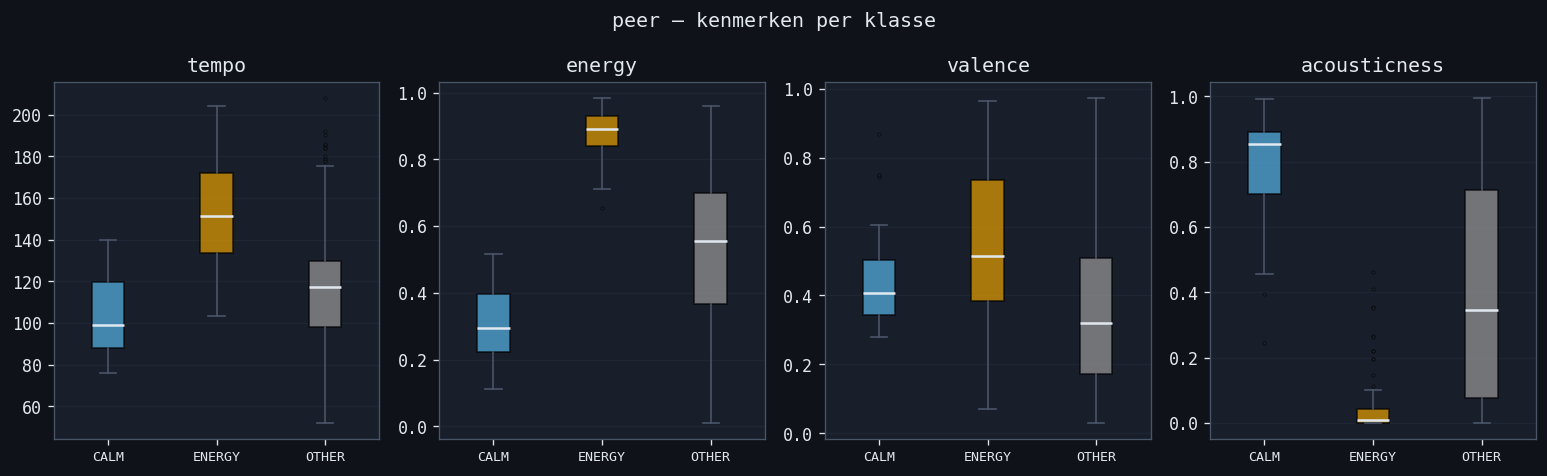

In [7]:
BOX_FEATURES = ["tempo", "energy", "valence", "acousticness"]

for codename in participants:
    df, _ = data[codename]

    fig, axes = plt.subplots(1, len(BOX_FEATURES), figsize=(13, 4))

    for ax, feat in zip(axes, BOX_FEATURES):
        groups = [df[df["class"] == cls][feat].dropna() for cls in CLASS_ORDER]
        bp = ax.boxplot(
            groups,
            patch_artist=True,
            medianprops={"color": "#e2e8f0", "linewidth": 1.5},
            whiskerprops={"color": "#4a5568"},
            capprops={"color": "#4a5568"},
            flierprops={"marker": ".", "markerfacecolor": "#4a5568", "markersize": 3, "alpha": 0.5},
        )
        for patch, cls in zip(bp["boxes"], CLASS_ORDER):
            patch.set_facecolor(CLASS_COLORS[cls])
            patch.set_alpha(0.7)

        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels([c.upper() for c in CLASS_ORDER], fontsize=8)
        ax.set_title(feat)
        ax.grid(True, axis="y", alpha=0.3)

    fig.suptitle(f"{codename} — kenmerken per klasse", fontsize=12)
    plt.tight_layout()
    plt.show()